Performing graphical visualizations on the cleaned dataset to understand the data distribution clearly

In [1]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(r'D:\E-Commerce_dynamic_system\src')

In [2]:
df=pd.read_csv(r'D:\E-Commerce_dynamic_system\data\processed\cleaned_products.csv',index_col=0)

In [3]:
from feature_engineering import engineer_all_features
df=engineer_all_features(df)

Univariate Analysis-Analysis on single column

In [4]:
df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,listed_price,is_best_seller,is_sponsored,is_couponed,sustainability_badges,...,discounted_amount,discount_pct,value_score,demand_score,estimated_revenue,price_category,revenue_leakage_pct,premium_price_flag,price_vs_avg,review_credibility
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,...,69.32,43.597484,0.051293,0.0030,26904.0,Mid-range,43.597484,0,0.532177,27.276110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,1,...,6.00,37.523452,0.430430,0.0600,59940.0,Budget,37.523452,0,0.059282,33.570544
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,1,...,35.00,10.028653,0.014650,0.0200,628000.0,Premium,10.028653,0,1.863333,36.897778
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,77.00,56.99,1,0,0,1,...,-20.01,-35.111423,0.059740,0.1000,770000.0,Mid-range,0.000000,1,0.456932,48.244887
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,77.00,56.99,0,0,0,1,...,-20.01,-35.111423,0.062338,0.1000,770000.0,Mid-range,0.000000,1,0.456932,49.318424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,56.99,0,0,0,1,...,-139.00,-243.902439,0.025512,0.0010,19599.0,Premium,0.000000,1,1.163040,3.465736
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,56.99,0,0,0,1,...,-33.00,-57.904896,0.046672,0.0020,17998.0,Mid-range,0.000000,1,0.534017,12.786994
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,56.99,0,0,0,1,...,-843.00,-1479.206878,0.004778,0.0005,44999.5,Premium,0.000000,1,5.340704,17.459905
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,0,0,0,1,...,5.59,34.981227,0.452358,0.0050,5195.0,Budget,34.981227,0,0.061656,41.680881


Price Distribution Analysis using histogram

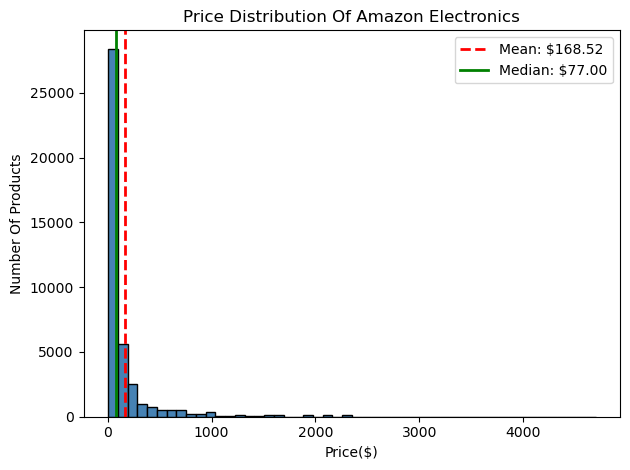

<Figure size 640x480 with 0 Axes>

In [5]:
plt.hist(df['current/discounted_price'],bins=50,color='steelblue',edgecolor='black')
mean_price = df['current/discounted_price'].mean()
median_price = df['current/discounted_price'].median()
# Mean line
plt.axvline(mean_price,color='red', linestyle='--',linewidth=2,label=f'Mean: ${mean_price:.2f}')
# Median line
plt.axvline(median_price,color='green',linestyle='-',linewidth=2,label=f'Median: ${median_price:.2f}')
plt.title("Price Distribution Of Amazon Electronics")
plt.xlabel("Price($)")
plt.ylabel("Number Of Products")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\price_distribution.png',
            dpi=300, bbox_inches='tight')

Rating Distribution

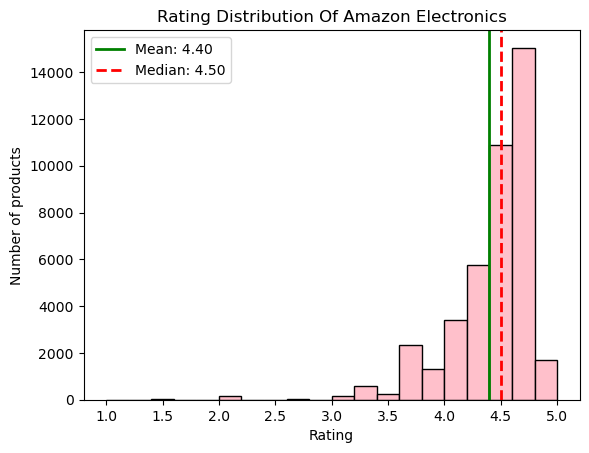

In [6]:

plt.hist(df['rating'],bins=20,color='pink',edgecolor='black')
mean_rating=df['rating'].mean()
median_rating=df['rating'].median()
plt.axvline(mean_rating,linestyle='-',linewidth=2,color='green',label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating,linestyle='--',linewidth=2,color='red',label=f'Median: {median_rating:.2f}')
plt.title("Rating Distribution Of Amazon Electronics")
plt.xlabel("Rating")
plt.ylabel("Number of products")
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\rating_distribution.png',
            dpi=300, bbox_inches='tight')
plt.legend()

Discount Percentage Distribution

In [7]:
df.columns

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'listed_price', 'is_best_seller',
       'is_sponsored', 'is_couponed', 'sustainability_badges', 'collected_at',
       'discounted_amount', 'discount_pct', 'value_score', 'demand_score',
       'estimated_revenue', 'price_category', 'revenue_leakage_pct',
       'premium_price_flag', 'price_vs_avg', 'review_credibility'],
      dtype='object')

In [8]:
df.loc[df['discount_pct']<0,['discounted_amount','discount_pct','current/discounted_price']].head(20)

,discounted_amount,discount_pct,current/discounted_price
3,-20.01,-35.111423,77.00
4,-20.01,-35.111423,77.00
5,-20.01,-35.111423,77.00
6,-20.01,-35.111423,77.00
7,-20.01,-35.111423,77.00
9,-20.01,-35.111423,77.00
11,-20.01,-35.111423,77.00
13,-193.00,-338.655905,249.99
14,-12.96,-22.740832,69.95
15,-20.01,-35.111423,77.00


In [9]:
(df['discount_pct']<0).sum()

23654

In [10]:
(df['discount_pct']<0).mean()*100

56.790953398477825

In [11]:
df[['listed_price', 'current/discounted_price']].describe()

,listed_price,current/discounted_price
count,41651.000000,41651.000000
mean,75.432252,168.515247
std,87.715638,316.766992
min,4.950000,2.490000
25%,56.990000,34.990000
50%,56.990000,77.000000
75%,56.990000,129.990000
max,999.990000,4699.000000


In [12]:
(df['listed_price'] > df['current/discounted_price']).mean() * 100

43.20424479604331

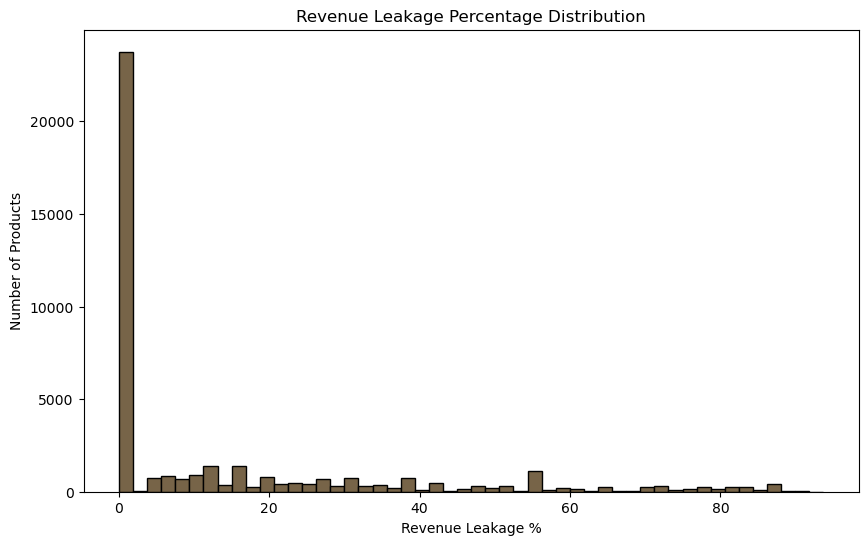

In [13]:
plt.figure(figsize=(10,6))
plt.hist(df['revenue_leakage_pct'],bins=50,color="#776448",edgecolor='black')
plt.title('Revenue Leakage Percentage Distribution')
plt.xlabel('Revenue Leakage %')
plt.ylabel('Number of Products')
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\revenue_leakage.png',
            dpi=300, bbox_inches='tight')

Price category piechart,to visualize the proportions of categories always use value_counts() which creates pandas series where counts.values → the actual numeric counts (how many times each category appears).
counts.index → the labels (the category names themselves).

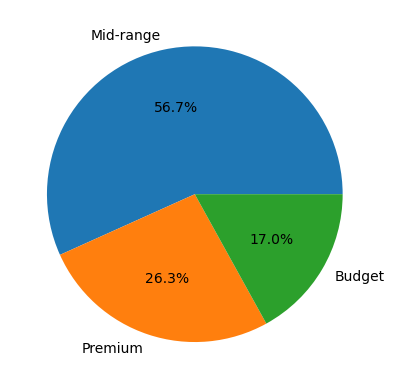

In [14]:
counts=df['price_category'].value_counts()
plt.pie(counts.values,labels=counts.index,autopct="%1.1f%%")
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\price_category.png',
            dpi=300, bbox_inches='tight')

Bivariate Analysis

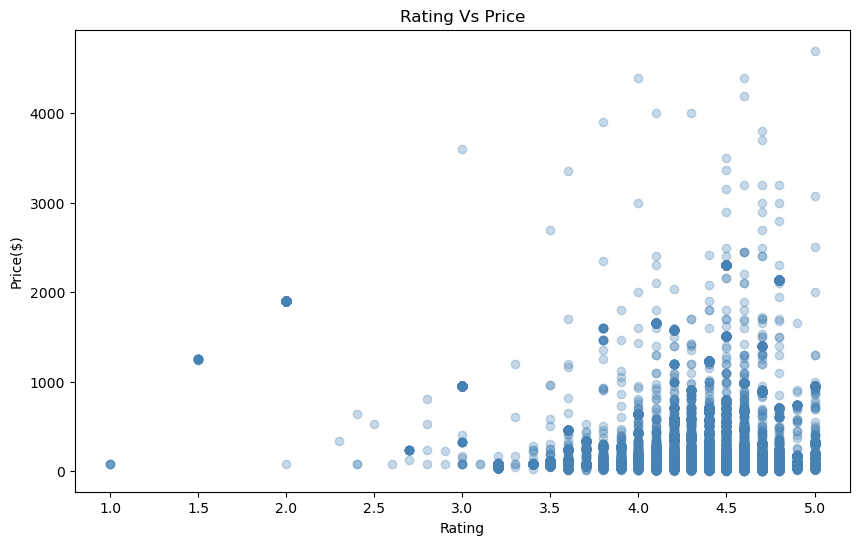

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df['rating'],df['current/discounted_price'],alpha=0.3,color='steelblue')
plt.title('Rating Vs Price')
plt.xlabel('Rating')
plt.ylabel('Price($)')
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\rating vs price.png',
            dpi=300, bbox_inches='tight')
plt.show()

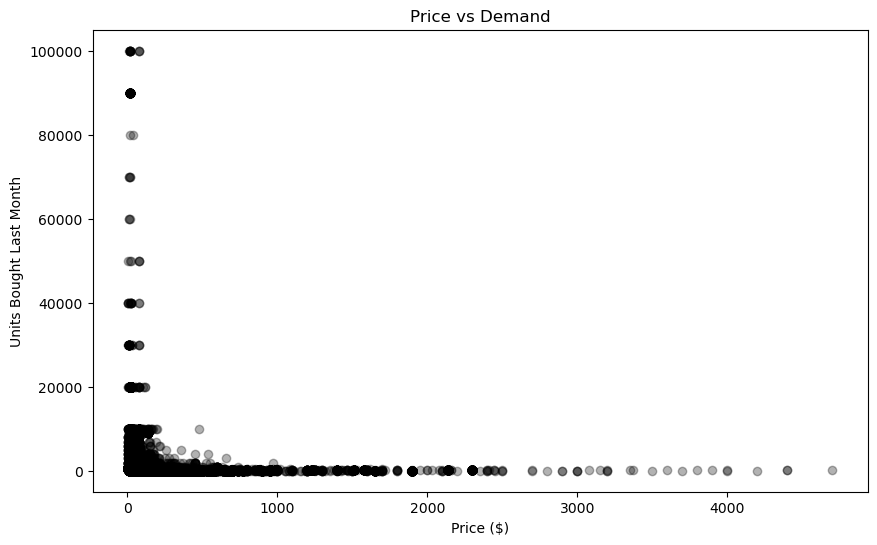

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(df['current/discounted_price'],df['bought_in_last_month'],alpha=0.3,color='black')
plt.title('Price vs Demand')
plt.xlabel('Price ($)')
plt.ylabel('Units Bought Last Month')
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\price_vs_demand.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\bharg\AppData\Local\Temp\ipykernel_21284\1626163598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_best_seller',y='current/discounted_price',data=df,palette='Set2')


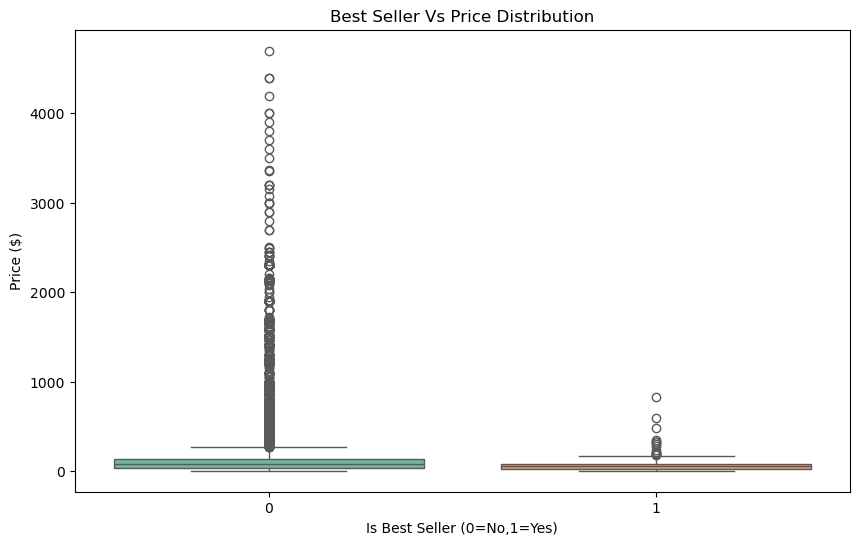

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_best_seller',y='current/discounted_price',data=df,palette='Set2')
plt.title('Best Seller Vs Price Distribution')
plt.xlabel('Is Best Seller (0=No,1=Yes)')
plt.ylabel('Price ($)')
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\best_seller vs price.png',
            dpi=300, bbox_inches='tight')

HeatMap shows which features related to price and helps select best features for ML model

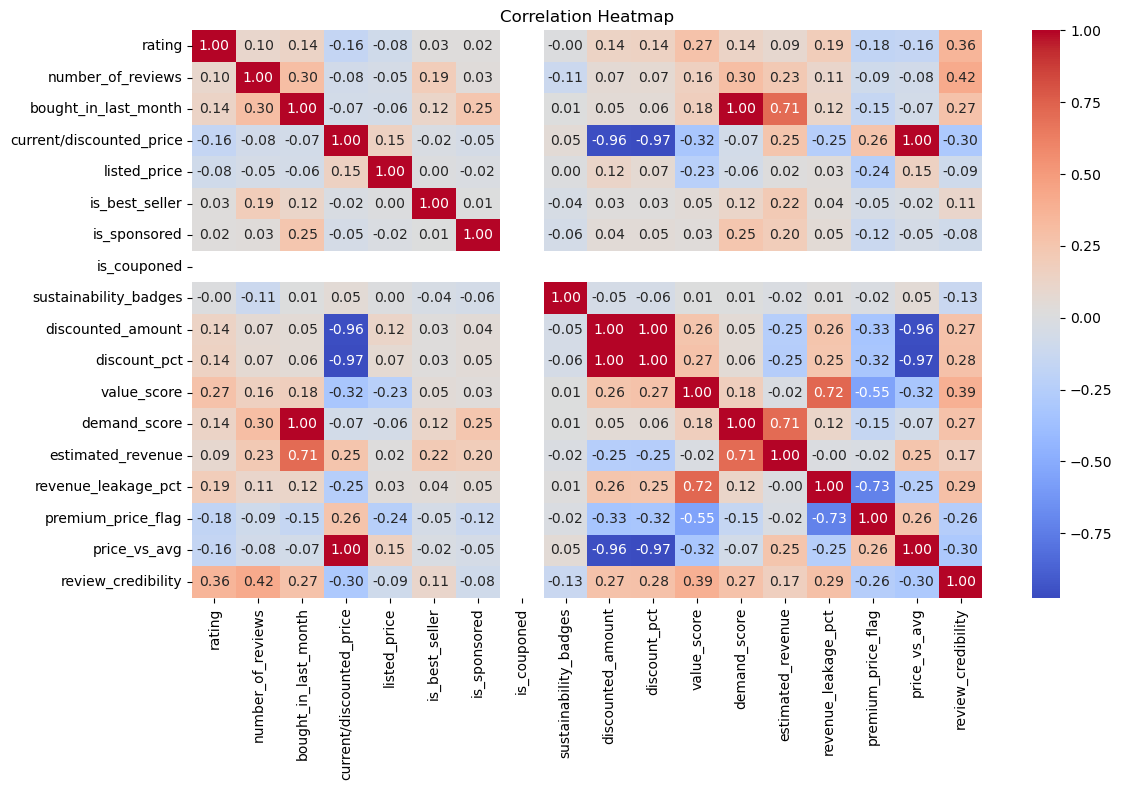

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\correlation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

Dropping some columns to avoid  redundancy(multicollinearity caused by highly correlated features) and data leakage caused by some engineered features derived from target variable.For ex: the target variable is current/discounted_price and the discounted_amount feature has derived from the target variable we need to remove this feature as the model may cheat instead of learning ..

In [19]:
drop_cols = [
    'discounted_amount',
    'discount_pct',
    'value_score',
    'estimated_revenue',
    'price_category',
    'price_vs_avg',
    'revenue_leakage_pct',
    'premium_price_flag'
]

model_df = df.drop(columns=drop_cols)

In [20]:
model_df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,listed_price,is_best_seller,is_sponsored,is_couponed,sustainability_badges,collected_at,demand_score,review_credibility
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,2025-08-21 11:14:29,0.0030,27.276110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,1,2025-08-21 11:14:29,0.0600,33.570544
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,1,2025-08-21 11:14:29,0.0200,36.897778
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,77.00,56.99,1,0,0,1,2025-08-21 11:14:29,0.1000,48.244887
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,77.00,56.99,0,0,0,1,2025-08-21 11:14:29,0.1000,49.318424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0010,3.465736
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0020,12.786994
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0005,17.459905
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,0,0,0,1,2025-08-30 19:56:33,0.0050,41.680881


In [21]:
model_df.shape

(41651, 13)

In [22]:
model_df.columns.tolist()

['title',
 'rating',
 'number_of_reviews',
 'bought_in_last_month',
 'current/discounted_price',
 'listed_price',
 'is_best_seller',
 'is_sponsored',
 'is_couponed',
 'sustainability_badges',
 'collected_at',
 'demand_score',
 'review_credibility']

In [23]:
model_df.isnull().sum()

title                       0
rating                      0
number_of_reviews           0
bought_in_last_month        0
current/discounted_price    0
listed_price                0
is_best_seller              0
is_sponsored                0
is_couponed                 0
sustainability_badges       0
collected_at                0
demand_score                0
review_credibility          0
dtype: int64

In [24]:
model_df['title']

0        BOYA BOYALINK 2 Wireless Lavalier Microphone f...
1        LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...
2        DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...
3        Apple AirPods Pro 2 Wireless Earbuds, Active N...
4        Apple AirTag 4 Pack. Keep Track of and find Yo...
                               ...                        
42670    Elgato 4K Pro, Internal Capture Card: 8K60 Pas...
42671    Arlo Essential Spotlight Camera, Wireless Secu...
42672    GIGABYTE - AORUS FO32U2-32" QD OLED Gaming Mon...
42673    Monoprice XLR Male to 1/4-Inch TRS Male Cable ...
42674    Lorex Fusion 1080p HD Security Camera System w...
Name: title, Length: 41651, dtype: object

Keep title separately for display

In [25]:
titles=model_df['title'].copy()

model_df has cleaned numerical features

In [26]:
model_df=model_df.drop(['title','collected_at'],axis=1)

Separating Features and Target Variable

In [27]:
X=model_df.drop('current/discounted_price',axis=1)
y=model_df['current/discounted_price']
print("Features Shape:",X.shape)
print("Target Shape:",y.shape)

Features Shape: (41651, 10)
Target Shape: (41651,)


Splitting the data for training and testing

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#scaling the features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


"I chose Random Forest Regressor because:

1. My data has non-linear relationships
   between price and other features

2. Dataset has 42,000+ products with
   mixed feature types and outliers
   which Random Forest handles robustly

3. Most importantly — Random Forest
   provides Feature Importance scores
   revealing WHICH factors most influence
   Amazon electronics pricing

4. It's more interpretable and explainable
   to business stakeholders

In Future I will also plan to compare with XGBoost
to benchmark performance!" 🎯

Training the model using different algorithms

DecisionTreeRegressor

In [50]:
#using DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
#passing some pre-pruning hyperparameters to reduce the overfitting,complexity and better performance
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
#fitting to model
dt.fit(X_train_scaled,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

RandomForestRegressor model

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error)
#creating model
rf_model=RandomForestRegressor( n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train_scaled,y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

XGBoost 

In [32]:
import sys
!{sys.executable} -m pip install xgboost

In [52]:
from xgboost import XGBRegressor
xgb=XGBRegressor(   n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42)
xgb.fit(X_train_scaled,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Creating reusable function to check the evaluation metrics values of diffent models at once

In [55]:
def evaluate(model,X_test_scaled,y_test):
    y_pred=model.predict(X_test_scaled)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,y_pred)
    return mae,mse,rmse,r2

In [56]:
#creating dict to store the evaluation results of various models
results={}
results['DecisionTreeModel']=evaluate(dt,X_test_scaled,y_test)
results['RandomForestModel']=evaluate(rf_model,X_test_scaled,y_test)
results['XGBoost Model']=evaluate(xgb,X_test_scaled,y_test)
print(results)

{'DecisionTreeModel': (50.010343407903854, 21520.49081998235, 146.69863946193348, 0.7702225273582102), 'RandomForestModel': (37.90034353546354, 15705.423204777926, 125.3212799359228, 0.8323108668407893), 'XGBoost Model': (40.7510682975363, 16879.84992718192, 129.92247660501982, 0.8197713385217418)}


MAE=​∑∣y−y^​∣/n where y-actual value and y^-predicted value,lowest mean absolute error is best
MSE=​∑(y−y^​)^2/n -lower value is better
RMSE=sqrt(MSE),rmse converts square units to original units,lower is better
R2=1−(SSTotal/​SSResidual​​) r2 helps us to know how well the model explains the variations of target variable,higher is better,1 is prefect prediction

In [57]:
comparison=pd.DataFrame(results,index=['MAE','MSE','RMSE','R2']).T
comparison

,MAE,MSE,RMSE,R2
DecisionTreeModel,50.010343,21520.490820,146.698639,0.770223
RandomForestModel,37.900344,15705.423205,125.321280,0.832311
XGBoost Model,40.751068,16879.849927,129.922477,0.819771


"I compared three ML models:
Decision Tree, Random Forest and XGBoost.

Random Forest performed best with:
→ R² of 0.832 (83.2% accuracy)
→ MAE of $37.92
→ RMSE of $125.41

It outperformed XGBoost (R²=0.820)
and Decision Tree (R²=0.770)

The model successfully predicts
Amazon electronics pricing within
$38 average error across 42,000+ products!"


In [37]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
9     review_credibility    0.373438
1      number_of_reviews    0.311313
0                 rating    0.163158
2   bought_in_last_month    0.050642
8           demand_score    0.046505
3           listed_price    0.037195
5           is_sponsored    0.014585
7  sustainability_badges    0.003105
4         is_best_seller    0.000059
6            is_couponed    0.000000


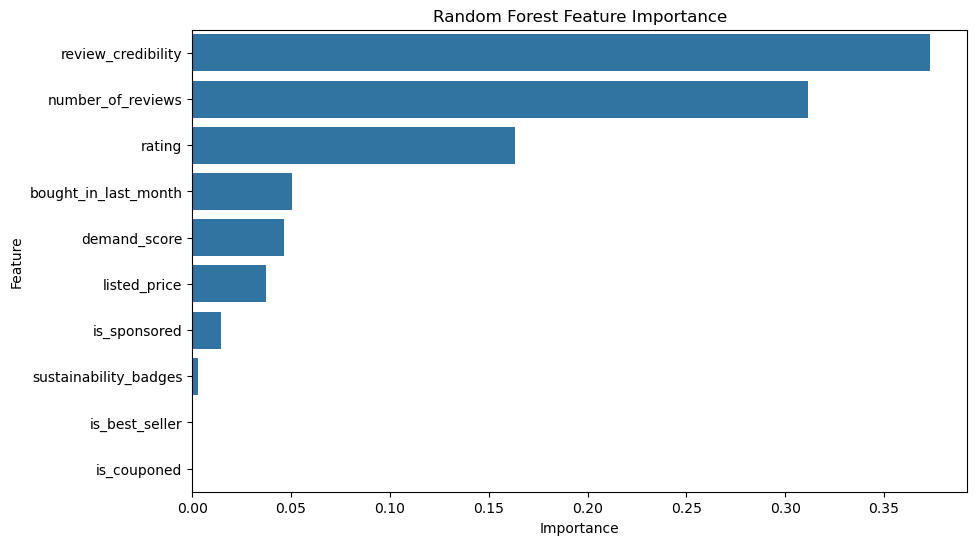

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.savefig(r'D:\E-Commerce_dynamic_system\outputs\charts\feature_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()

As some of the features are less influencing or almost having 0% in prediction part of electronics pricing.So we can evaluate the model performance again after deleting the less useful features like is_couponed,is_best_seller,and sustainability_badges

Retraining by deleting the some features

In [58]:
from sklearn.preprocessing import StandardScaler
X_clean=X.drop(['is_couponed','is_best_seller','sustainability_badges'],axis=1)
X_train,X_test,y_train,y_test=train_test_split(X_clean,y,test_size=0.2,random_state=42)
#Feature Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [63]:
#training the model again to check the performance
rf_model2=RandomForestRegressor(n_estimators=100, max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
rf_model2.fit(X_train_scaled,y_train)
#testing
y_pred2=rf_model2.predict(X_test_scaled)
#evaluate
r2_model2=r2_score(y_pred2,y_test)
mae=mean_absolute_error(y_pred2,y_test)
rmse=np.sqrt(mean_squared_error(y_pred2,y_test))
#printing
print(f"After_reduction_R2 score:{r2_model2:.4f}")
print(f"After_reduction_MAE:{mae:.2f}")
print(f"After_reduction_RMSE:{rmse:.2f}")

After_reduction_R2 score:0.7889
After_reduction_MAE:33.70
After_reduction_RMSE:123.65


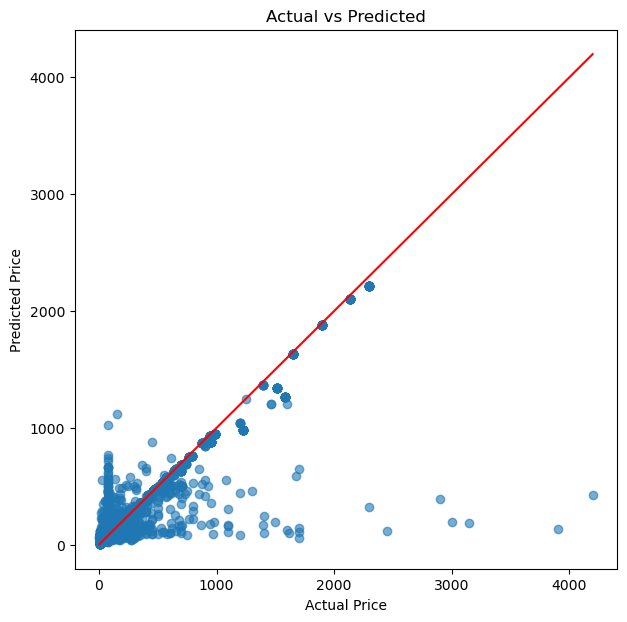

In [65]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_model2.predict(X_test_scaled), alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

The model underestimates expensive products,actual price>predicted price
Possible Reason:Dataset might be unbalanced

Residuals Inspecting

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


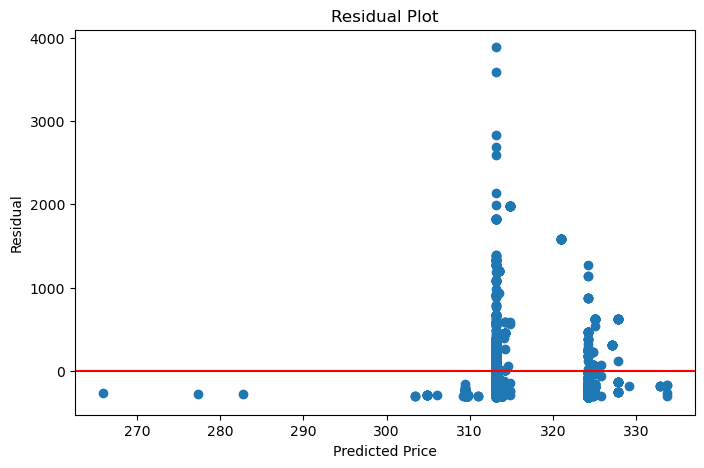

In [67]:
residuals = y_test - rf_model2.predict(X_test)

plt.figure(figsize=(8,5))

plt.scatter(rf_model2.predict(X_test), residuals)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Saving the Model

In [72]:
import joblib
#saving the model
joblib.dump(rf_model,r'D:\E-Commerce_dynamic_system\outputs\models\rf_model.pxl')
joblib.dump(scaler,r"D:\E-Commerce_dynamic_system\outputs\models\scaler.pxl")
print("Model Saved Successfully")


Model Saved Successfully


After training the Random Forest model, we save the names and order of the input features in a .pkl file.
Since the model learns using a specific set of features in a fixed order. During deployment, the API must provide the input data in the exact same order as the model was trained on.
If the feature order changes or any feature is missing, the model may interpret the inputs incorrectly, resulting in inaccurate predictions.